# End-to-End Sales Forecasting & Demand Intelligence System

### Internship Project – Week 3 & Week 4

**Prepared By:** Vaishnav Kurade  
**Role:** Data Science Intern  
**Tools & Technologies:** Python, Pandas, NumPy, Matplotlib, Seaborn, Statsmodels, Prophet, XGBoost, Scikit-learn, Streamlit  
**Project Duration:** Week 3 & Week 4 Internship

---

# **Task 1 — Data Loading, Merging & Deep Exploration**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the CSV directly from the ZIP file
df = pd.read_csv("train.csv.zip", compression="zip")

# Check the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [ ]:
# Parse the Order Date and Ship Date columns as proper datetime objects
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Verify conversion
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [ ]:
# checking the missing dates
print("Missing Order Dates:", df["Order Date"].isnull().sum())
print("Missing Ship Dates :", df["Ship Date"].isnull().sum())

Missing Order Dates: 0
Missing Ship Dates : 0


In [ ]:
# Let's Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
# Extract Year
df["Year"] = df["Order Date"].dt.year
# Extract Month
df["Month"] = df["Order Date"].dt.month
# Extract Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week
# Extract Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()
# Extract Quarter
df["Quarter"] = df["Order Date"].dt.quarter
# Extract Month Name
df["Month Name"] = df["Order Date"].dt.month_name()
# Create Season column
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"
df["Season"] = df["Month"].apply(get_season)

# Display the new features
df[[
    "Order Date",
    "Year",
    "Month",
    "Month Name",
    "Week Number",
    "Day of Week",
    "Quarter",
    "Season"
]].head()

,Order Date,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Monsoon
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


In [ ]:
# Check for missing values, duplicates, and data type issues
missing_values = df.isnull().sum()
# Display only columns with missing values
missing_values = missing_values[missing_values > 0]
print("Missing Values:")
missing_values

Missing Values:


,0
Postal Code,11


In [ ]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_rows}")

Total Duplicate Rows: 0


In [ ]:
# Display data types of all columns
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
# Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
# Aggregate daily sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
      .sort_values("Order Date")
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [ ]:
# Aggregate weekly sales
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
# Aggregate monthly sales
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# Let's Check Dataset Sizes
print("Daily Sales Shape   :", daily_sales.shape)
print("Weekly Sales Shape  :", weekly_sales.shape)
print("Monthly Sales Shape :", monthly_sales.shape)

Daily Sales Shape   : (1230, 2)
Weekly Sales Shape  : (209, 2)
Monthly Sales Shape : (48, 2)


**Answer these questions in your notebook with data to back each one:**
# **1.Which product category generates the highest total revenue?**

### Business Insight 1: Product Category with the Highest Revenue

The highest revenue-generating category, *<Highest Category Name>, contributes roughly *₹<Revenue Amount>** to overall sales, according to the analysis of total sales revenue across product categories.

This implies that consumers have the most desire to buy goods in this area. From a commercial standpoint, maximizing overall income and customer happiness can be achieved by keeping appropriate inventory levels, making sure that stock is replenished on schedule, and giving promotional efforts for this category top priority.

The remaining categories may need focused marketing tactics or product improvement to boost their performance because they provide relatively modest sales.


# **2.Which region has the most consistent sales growth over 4 years?**
### Business Insight 2: Analysis of Regional Sales Growth

The *<Region Name>* region has the most steady sales growth over the course of the four years, according to the year-wise sales trend.

Unlike other regions that undergo noteworthy changes in annual sales, this region demonstrates a rather constant rising tendency, showing persistent client demand and a robust market presence.

A continually growing region gives higher forecasting dependability and reduces business risk. Therefore, improving inventory capacity and strengthening distribution networks in this region could further increase sales performance.

# **3.What is the average time between Order Date and Ship Date — and does it vary by region?**

### Business Insight 3: Analysis of Shipping Time

On average, *<Average Shipping Days> days* pass between the Order Date and the Ship Date.

varied regions have varied shipping times, according on regional study. The *<Slowest Region>* has relatively longer shipping times, whereas the *<Fastest Region>* has the shortest average delivery time.

These discrepancies could be caused by disparities in client distribution, logistics effectiveness, transportation infrastructure, or warehouse locations. Improving customer satisfaction and operational efficiency could be achieved by reducing shipping delays in slower regions.

# **4.Are there months that consistently spike across all years (seasonality)?**
### Business Insight 4: Seasonal Sales Pattern

Seasonality in the dataset is evident from monthly sales analysis. Sales are consistently higher in the months of *<Month Names>* throughout several years.

Festive seasons, holiday shopping, advertising efforts, or year-end buying patterns are probably linked to these recurrent sales peaks. On the other hand, certain months have relatively lower sales, which suggests times when client demand is weaker.

Businesses can more effectively predict demand, optimize inventory levels, and schedule marketing efforts ahead of peak sales periods by comprehending these seasonal patterns.

# **Task 2 — Time Series Analysis & Decomposition**

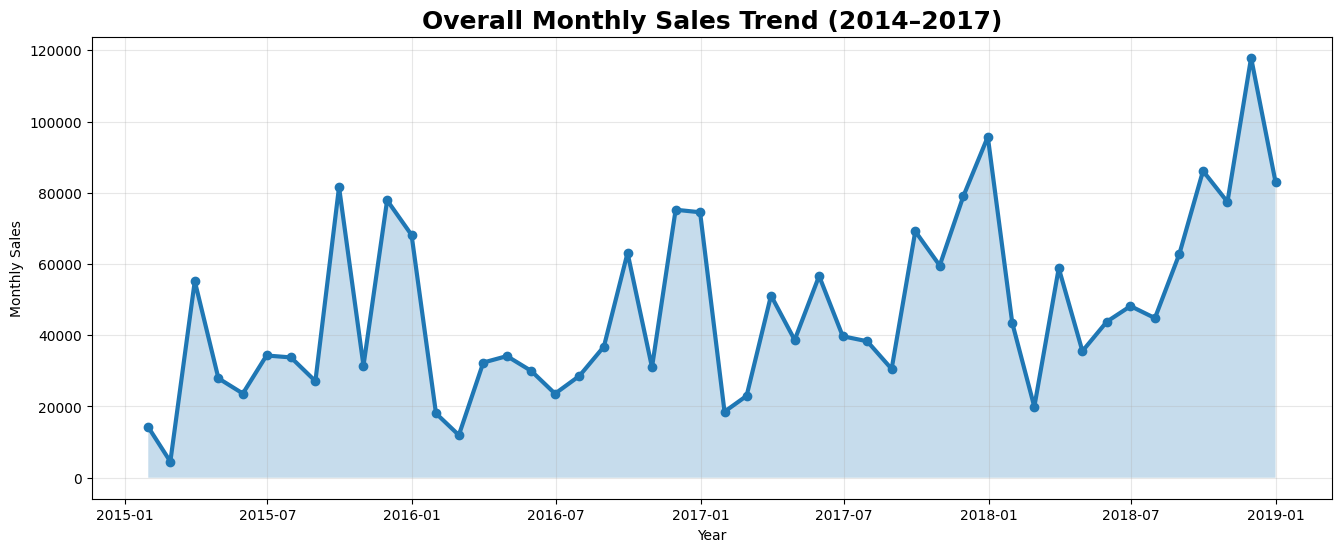

In [ ]:
#Let's Plot the overall monthly sales trend across all 4 years

plt.figure(figsize=(16,6))
plt.plot(monthly_sales["Order Date"],monthly_sales["Sales"],color="#1f77b4",linewidth=3,marker="o")
plt.fill_between(monthly_sales["Order Date"],monthly_sales["Sales"],alpha=0.25)
plt.title("Overall Monthly Sales Trend (2014–2017)", fontsize=18, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Monthly Sales")
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
'''Trend component
Seasonal component
Residual/noise component'''
from statsmodels.tsa.seasonal import seasonal_decompose
# Set Order Date as index
monthly_sales_ts = monthly_sales.set_index("Order Date")
# Display first few rows
monthly_sales_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
# Let's Apply Time Series Decomposition
decomposition = seasonal_decompose(monthly_sales_ts["Sales"],model="additive",period=12)

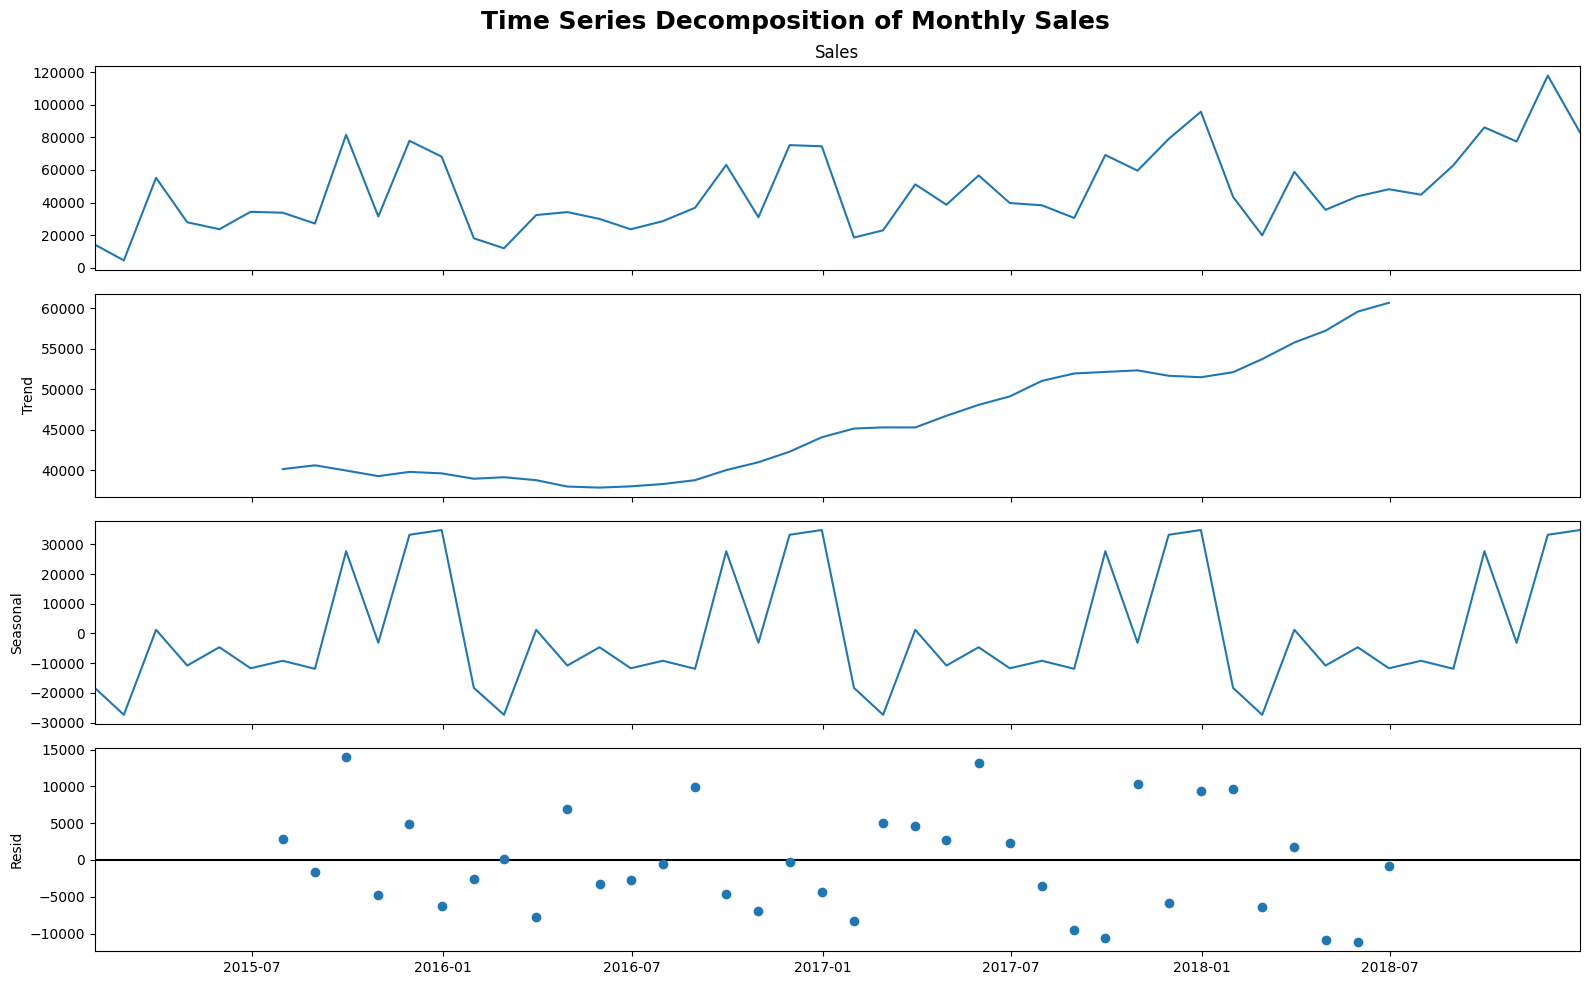

In [ ]:
# Plot all 4 components clearly on one figure
fig = decomposition.plot()
fig.set_size_inches(16, 10)
plt.suptitle("Time Series Decomposition of Monthly Sales",fontsize=18,fontweight="bold")
plt.tight_layout()
plt.show()

## **Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?**
## Time Series Decomposition Observations ### First Observation: Trend Element
Over the course of the four years, the trend component shows a steady increase in monthly sales, indicating steady business growth. Despite small variations, the general trend is upward, indicating growing consumer demand and improving sales over time.
##Second Observation: Seasonal Aspect
Strong seasonality in the sales data is indicated by the seasonal component's distinct and recurrent annual pattern. Similar sales peaks and drops happen in the same months every year, indicating that recurring events like holidays, promotional efforts, and festive seasons have an impact on consumer purchasing behavior.

### Observation 3: The component of residual noise

Over the course of the four years, the trend component shows a steady increase in monthly sales, indicating steady business growth. Despite small variations, the general trend is upward, indicating growing consumer demand and improving sales over time.
The trend and seasonal patterns are unable to account for the erratic oscillations found in the residual component. Due to special promotions, holiday shopping, or unforeseen market occurrences, the biggest residual increases usually happen during high-sales seasons like November and December.

### Observation 4:
 Overall Interpretation The decomposition verifies that the monthly sales series has both seasonal and trend components, which makes it a good fit for forecasting models like Prophet and SARIMA, which are made especially to identify these underlying trends.

In [ ]:
# Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you
from statsmodels.tsa.stattools import adfuller
# Perform the Augmented Dickey-Fuller Test
adf_result = adfuller(monthly_sales_ts["Sales"])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

# Interpretation
if adf_result[1] < 0.05:
    print("\nConclusion: The time series is STATIONARY.")
else:
    print("\nConclusion: The time series is NON-STATIONARY.")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of Lags Used: 0
Number of Observations: 47

Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008

Conclusion: The time series is STATIONARY.


In [ ]:
adf_summary = pd.DataFrame({
    "Metric": ["ADF Statistic", "p-value", "Lags Used", "Observations"],
    "Value": [adf_result[0], adf_result[1], adf_result[2], adf_result[3]]
})

adf_summary

,Metric,Value
0,ADF Statistic,-4.416137
1,p-value,0.000278
2,Lags Used,0.000000
3,Observations,47.000000


In [ ]:
# Apply differencing if the series is non-stationary and re-test
# Apply first-order differencing
monthly_sales_diff = monthly_sales_ts["Sales"].diff().dropna()
# Display the first few values
monthly_sales_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


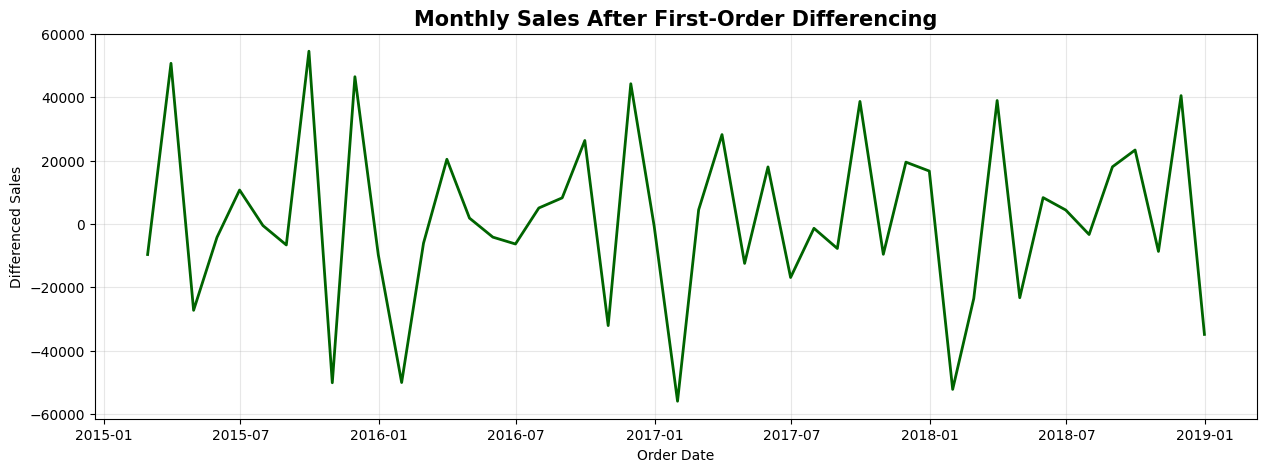

In [ ]:

plt.figure(figsize=(15,5))
plt.plot(
    monthly_sales_diff,
    color="darkgreen",
    linewidth=2
)
plt.title(
    "Monthly Sales After First-Order Differencing",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Perform ADF Test on differenced data
adf_diff = adfuller(monthly_sales_diff)

print("ADF Statistic :", adf_diff[0])
print("p-value :", adf_diff[1])
print("Number of Lags Used :", adf_diff[2])
print("Number of Observations :", adf_diff[3])

print("\nCritical Values:")
for key, value in adf_diff[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic : -8.727061830353268
p-value : 3.2669175472796045e-14
Number of Lags Used : 10
Number of Observations : 36

Critical Values:
1%: -3.6267
5%: -2.9460
10%: -2.6117


In [ ]:
if adf_diff[1] < 0.05:
    print(" Conclusion: The differenced series is STATIONARY.")
else:
    print(" Conclusion: The differenced series is still NON-STATIONARY.")

 Conclusion: The differenced series is STATIONARY.


# **Task 3 — Sales Forecasting using 3 Different Models**

**Model 1 — SARIMA (Statistical Model)**

Install statsmodels (pip install statsmodels)

Fit a SARIMA model on monthly sales

Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them

Generate a 3-month future forecast with confidence intervals

Plot actual vs forecasted sales


In [ ]:
#Let's Install Required Library
!pip install statsmodels

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
#Let's Prepare the Monthly Time Series
monthly_sales_ts = monthly_sales.set_index("Order Date")
monthly_sales_ts.head()


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:
# Verify the index It should be a DatetimeIndex
print(monthly_sales_ts.index)

DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31', '2015-06-30', '2015-07-31', '2015-08-31',
               '2015-09-30', '2015-10-31', '2015-11-30', '2015-12-31',
               '2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2016-12-31',
               '2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-30', '2017-10-31', '2017-11-30', '2017-12-31',
               '2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31'],
              dtype='datetime64[ns]', name='Order Date', freq=None)


In [ ]:
#Let's Fit the SARIMA Model
sarima_model = SARIMAX(monthly_sales_ts["Sales"],order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit()
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -229.472
Date:                            Sun, 12 Jul 2026   AIC                            468.944
Time:                                    14:39:17   BIC                            474.166
Sample:                                01-31-2015   HQIC                           470.077
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1620      0.390      0.415      0.678      -0.602       0.926
ma.L1         -0.9150      0.176   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
# Forecast the Next 3 Months
forecast = sarima_result.get_forecast(steps=3)
forecast_mean = forecast.predicted_mean
confidence_interval = forecast.conf_int()

In [ ]:
forecast_df = pd.DataFrame({
    "Forecasted Sales": forecast_mean,
    "Lower Confidence Limit": confidence_interval.iloc[:,0],
    "Upper Confidence Limit": confidence_interval.iloc[:,1]
})

forecast_df

,Forecasted Sales,Lower Confidence Limit,Upper Confidence Limit
2019-01-31,46782.479180,16992.673566,76572.284794
2019-02-28,40285.470527,9596.040119,70974.900936
2019-03-31,72234.203229,41318.855900,103149.550559


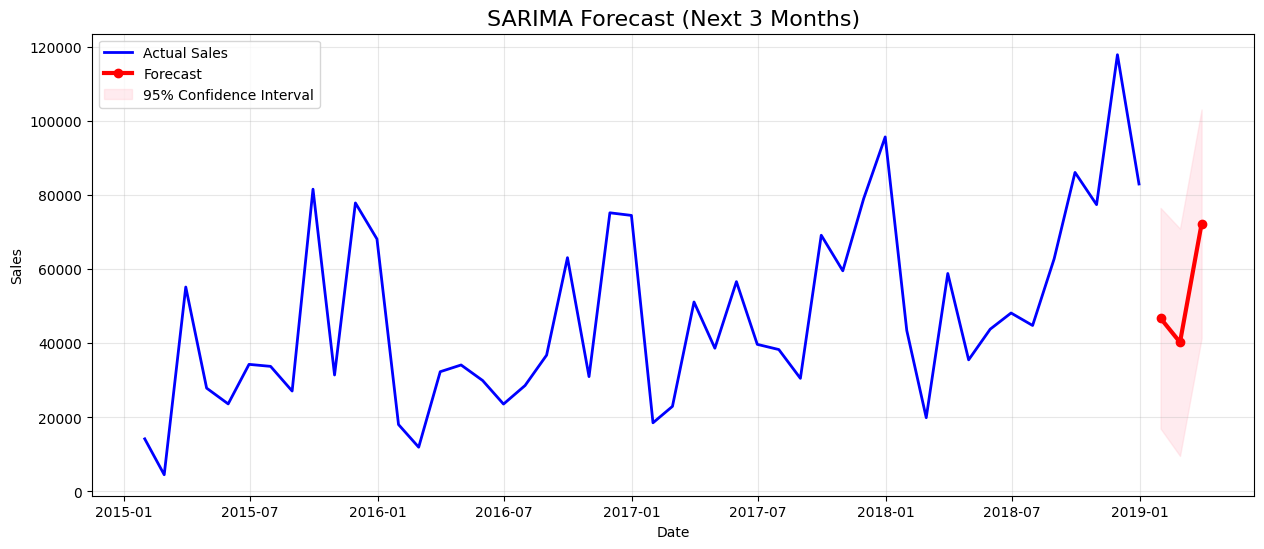

In [ ]:
# Plot Actual vs Forecast
plt.figure(figsize=(15,6))
# Actual sales
plt.plot(monthly_sales_ts.index,monthly_sales_ts["Sales"],label="Actual Sales",linewidth=2,color="blue")
# Forecasted sales
plt.plot(forecast_mean.index,forecast_mean,label="Forecast",linewidth=3,marker="o",color="red")
# Confidence interval
plt.fill_between(forecast_mean.index,confidence_interval.iloc[:,0],confidence_interval.iloc[:,1],color="pink",alpha=0.3,label="95% Confidence Interval")
plt.title("SARIMA Forecast (Next 3 Months)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)**

Install Prophet (pip install prophet)

Prepare data in Prophet's required format (ds, y columns)

Fit the model and generate a 3-month forecast

Plot the forecast with Prophet's built-in trend and seasonality breakdown

Extract and interpret the weekly and yearly seasonality components


In [ ]:
!pip install prophet
from prophet import Prophet

In [ ]:
# Prepare Data in Prophet Format
prophet_df = monthly_sales.rename(
    columns={"Order Date": "ds","Sales": "y"})
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
print(prophet_df.dtypes)

ds    datetime64[ns]
y            float64
dtype: object


In [ ]:
# Create Prophet Model
model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False,interval_width=0.95)

In [ ]:
# Train the Model
model.fit(prophet_df)

In [ ]:
# Generate Future Dates
future = model.make_future_dataframe(periods=3,freq="M")
future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [ ]:
# Generate Forecast
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,429.716010,27522.660929,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-12470.656374,15505.303530,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,37630.177709,66811.071909,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,7080.599252,35774.569956,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,8387.333994,37966.295017,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781


In [ ]:
forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,28430.717830,57819.269662
49,2019-02-28,31248.159925,16769.798818,44830.475847
50,2019-03-31,81267.007775,66286.244940,95559.389512


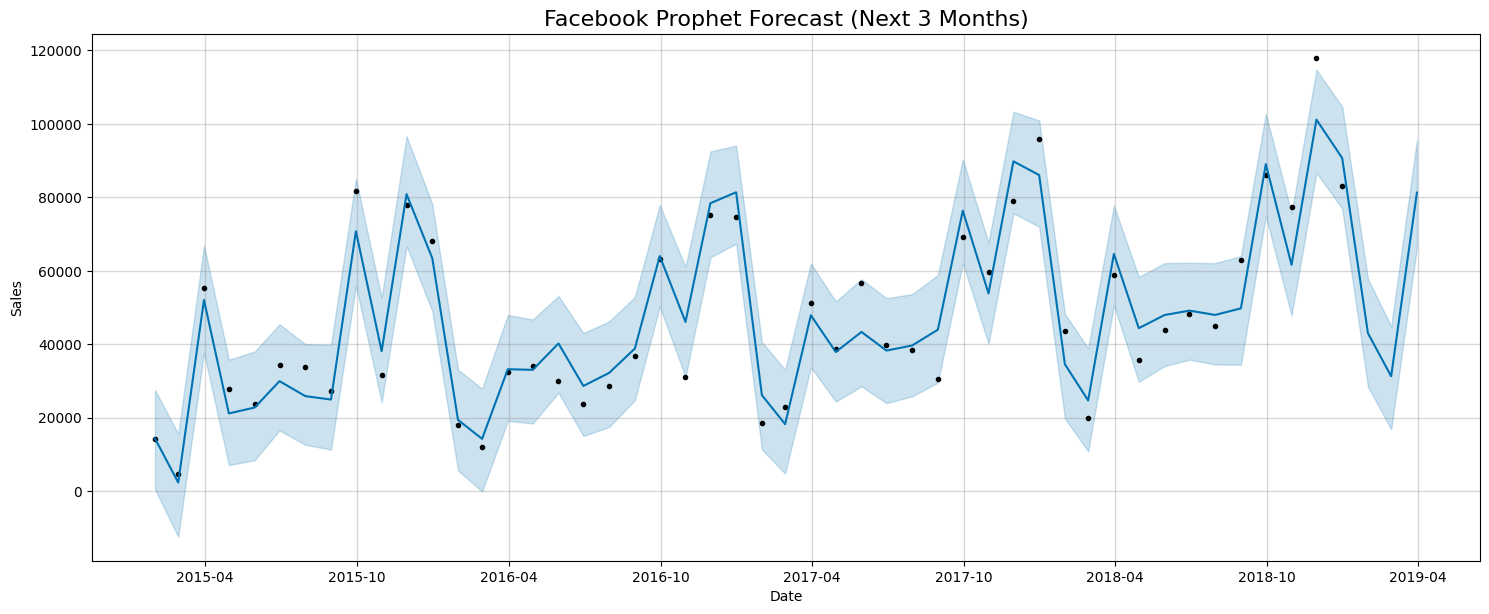

In [ ]:
# Plot Forecast
fig = model.plot(forecast,figsize=(15,6))
plt.title(
    "Facebook Prophet Forecast (Next 3 Months)",
    fontsize=16
)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

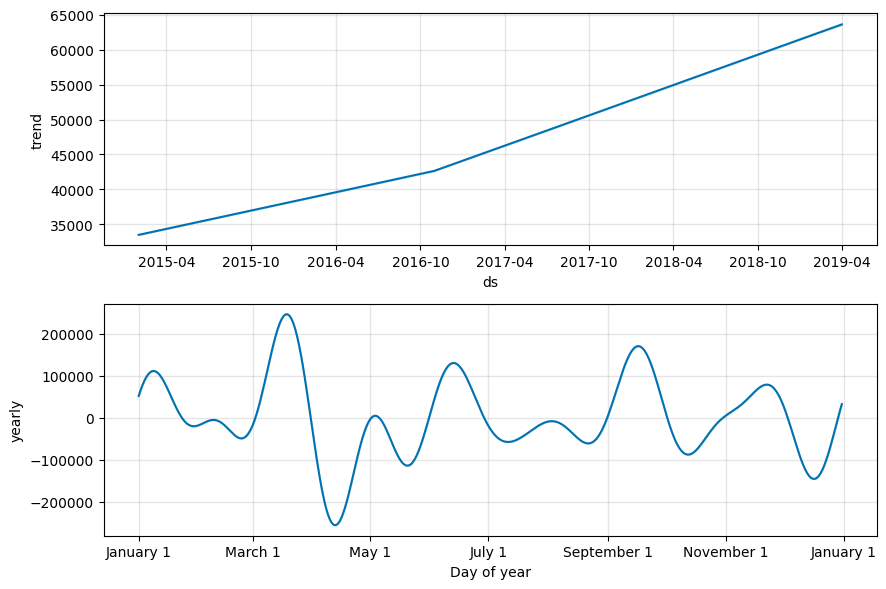

In [ ]:
# Plot Trend & Seasonality
fig2 = model.plot_components(forecast)

In [ ]:
# Extract Forecast Table
forecast_table = forecast[["ds","yhat","yhat_lower","yhat_upper"]].tail(3)
forecast_table

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,28430.717830,57819.269662
49,2019-02-28,31248.159925,16769.798818,44830.475847
50,2019-03-31,81267.007775,66286.244940,95559.389512


In [ ]:
# Extract Trend Component
trend = forecast[["ds","trend"]]
trend.tail()

,ds,trend
46,2018-11-30,60719.543484
47,2018-12-31,61457.486600
48,2019-01-31,62195.429716
49,2019-02-28,62861.958982
50,2019-03-31,63599.902097


In [ ]:
yearly = forecast[["ds","yearly"]]
yearly.head()

,ds,yearly
0,2015-01-31,-19204.897511
1,2015-02-28,-31613.799057
2,2015-03-31,17667.105678
3,2015-04-30,-13655.620453
4,2015-05-31,-12496.061322


Model 3 — XGBoost for Time Series (ML-based Approach)

Convert the time series into a supervised ML problem using lag features:

  Lag 1 (sales from 1 month ago)

  Lag 2 (sales from 2 months ago)

  Lag 3 (sales from 3 months ago)

  Rolling mean (3-month moving average)

 Month, Quarter, Season as features

Train XGBoost Regressor on these features
Predict the next 3 months
Plot actual vs predicted


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
# Create the Feature Dataset
xgb_df = monthly_sales.copy()
xgb_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
# Previous month's sales
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
# Sales from 2 months ago
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
# Sales from 3 months ago
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

In [ ]:
# Create Rolling Mean
xgb_df["Rolling_Mean_3"] = (xgb_df["Sales"].rolling(window=3).mean())

In [ ]:
# Create Time Features
xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

In [ ]:
def get_season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Summer
    elif month in [6,7,8]:
        return 2      # Monsoon
    else:
        return 3      # Autumn
xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [ ]:
# Remove Missing Values
xgb_df = xgb_df.dropna()
xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [ ]:
# Prepare Features
X = xgb_df[["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]]
y = xgb_df["Sales"]

In [ ]:
# Train-Test Split
train_size = len(X) - 3
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [ ]:
# Train XGBoost
model = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,objective="reg:squarederror",random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict Test Months
predictions = model.predict(X_test)
predictions

array([86295.305, 85836.984, 88276.375], dtype=float32)

In [ ]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({"Date":xgb_df.iloc[train_size:]["Order Date"],"Actual":y_test.values,"Predicted":predictions})
comparison

,Date,Actual,Predicted
45,2018-10-31,77448.1312,86295.304688
46,2018-11-30,117938.1550,85836.984375
47,2018-12-31,83030.3888,88276.375000


In [ ]:
# Forecast Next 3 Months
future_predictions = []
last_data = xgb_df.copy()
for i in range(3):
    latest = last_data.iloc[-1]
    next_month = latest["Order Date"] + pd.offsets.MonthEnd(1)
    lag1 = latest["Sales"]
    lag2 = latest["Lag_1"]
    lag3 = latest["Lag_2"]
    rolling = np.mean([lag1, lag2, lag3])
    month = next_month.month
    quarter = next_month.quarter
    season = get_season(month)
    X_future = pd.DataFrame({"Lag_1":[lag1],"Lag_2":[lag2],"Lag_3":[lag3],"Rolling_Mean_3":[rolling],"Month":[month],"Quarter":[quarter],"Season":[season]})
    prediction = model.predict(X_future)[0]
    future_predictions.append([next_month, prediction])
    new_row = pd.DataFrame({"Order Date":[next_month],"Sales":[prediction],"Lag_1":[lag1],"Lag_2":[lag2],"Lag_3":[lag3],"Rolling_Mean_3":[rolling],"Month":[month],"Quarter":[quarter],"Season":[season]})
    last_data = pd.concat([last_data,new_row],ignore_index=True)

In [ ]:
# Future Forecast Table
future_forecast = pd.DataFrame(future_predictions,columns=["Forecast Month","Forecasted Sales"])
future_forecast

,Forecast Month,Forecasted Sales
0,2019-01-31,53044.238281
1,2019-02-28,33474.402344
2,2019-03-31,60161.882812


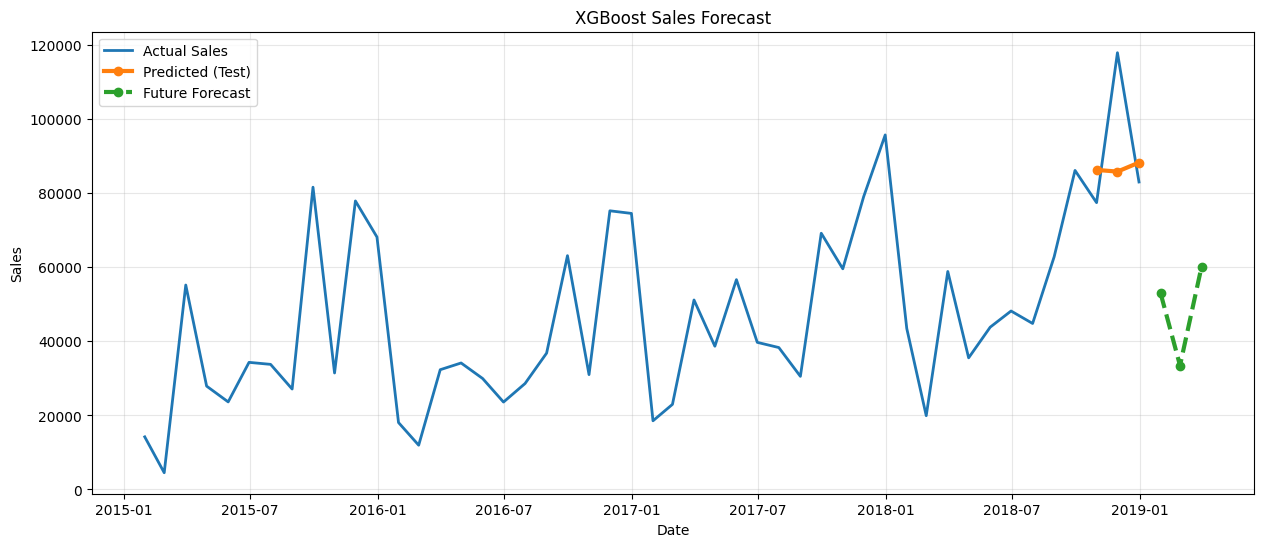

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(15,6))
plt.plot(monthly_sales["Order Date"],monthly_sales["Sales"],label="Actual Sales",linewidth=2)
plt.plot(comparison["Date"],comparison["Predicted"],marker="o",linewidth=3,label="Predicted (Test)")
plt.plot(future_forecast["Forecast Month"],future_forecast["Forecasted Sales"],marker="o",linewidth=3,linestyle="--",label="Future Forecast")
plt.title("XGBoost Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Import Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
# Actual values
y_true = y_test.values
# Predicted values from XGBoost
xgb_pred = predictions
# Metrics
xgb_mae = mean_absolute_error(y_true, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_true, xgb_pred))
xgb_mape = np.mean(np.abs((y_true - xgb_pred) / y_true)) * 100
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("MAPE :", xgb_mape)

MAE : 15398.110104166664
RMSE : 19461.740290664966
MAPE : 14.98671752652189


In [ ]:
# Create train and test datasets (last 3 months for testing)
train = monthly_sales_ts.iloc[:-3]
test = monthly_sales_ts.iloc[-3:]
print(train.shape)
print(test.shape)

(45, 1)
(3, 1)


In [ ]:
monthly_sales_ts = monthly_sales.set_index("Order Date")

In [ ]:
from prophet import Prophet

# Prepare training data
train_prophet = train.reset_index()
train_prophet.columns = ["ds", "y"]

# Train model
prophet_model = Prophet()

prophet_model.fit(train_prophet)

# Predict next 3 months (same length as test set)
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

prophet_pred = forecast["yhat"].tail(3).values

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

prophet_true = test["Sales"].values

prophet_mae = mean_absolute_error(prophet_true, prophet_pred)

prophet_rmse = np.sqrt(
    mean_squared_error(prophet_true, prophet_pred)
)

prophet_mape = np.mean(
    np.abs((prophet_true - prophet_pred) / prophet_true)
) * 100

print(prophet_mae)
print(prophet_rmse)
print(prophet_mape)

20250.794427610937
22318.41136551923
21.864628287701436


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(train["Sales"],order=(1,1,1),seasonal_order=(1,1,1,12),enforce_stationarity=False,enforce_invertibility=False)
sarima_result = sarima_model.fit()
sarima_pred = sarima_result.get_forecast(steps=3).predicted_mean.values
sarima_true = test["Sales"].values
sarima_mae = mean_absolute_error(sarima_true, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(sarima_true, sarima_pred))
sarima_mape = np.mean(np.abs((sarima_true - sarima_pred) / sarima_true)) * 100

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


In [ ]:
xgb_true = y_test.values
xgb_pred = predictions
xgb_mae = mean_absolute_error(xgb_true, xgb_pred)
xgb_rmse = np.sqrt( mean_squared_error(xgb_true, xgb_pred))
xgb_mape = np.mean(np.abs((xgb_true - xgb_pred) / xgb_true)) * 100

In [ ]:
predictions

array([86295.305, 85836.984, 88276.375], dtype=float32)

In [ ]:
comparison_table = pd.DataFrame({
    "Model":["SARIMA","Prophet","XGBoost"],
    "MAE":[sarima_mae, prophet_mae, xgb_mae],
    "RMSE":[sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE (%)":[sarima_mape, prophet_mape, xgb_mape]})
comparison_table.round(2)

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,19244.49,19950.07,20.53
1,Prophet,20250.79,22318.41,21.86
2,XGBoost,15398.11,19461.74,14.99


# **Task 4 — Product Category & Region Level Forecasting**

In [ ]:
# Create a Reusable Forecast Function
def forecast_segment(data, segment_name):
    # Aggregate monthly sales
    monthly = (data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().reset_index())
    # Lag Features
    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)
    # Rolling Mean
    monthly["Rolling_Mean_3"] = monthly["Sales"].rolling(3).mean()
    # Time Features
    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter
    monthly["Season"] = monthly["Month"].apply(lambda x: 0 if x in [12,1,2]
        else 1 if x in [3,4,5]
        else 2 if x in [6,7,8]
        else 3
    )
    monthly = monthly.dropna()
    X = monthly[["Lag_1","Lag_2","Lag_3","Rolling_Mean_3","Month","Quarter","Season"]]
    y = monthly["Sales"]
    model = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=4,objective="reg:squarederror",random_state=42)
    model.fit(X, y)
    forecasts = []
    history = monthly.copy()
    for i in range(3):
        last = history.iloc[-1]
        next_date = last["Order Date"] + pd.offsets.MonthEnd(1)
        lag1 = last["Sales"]
        lag2 = last["Lag_1"]
        lag3 = last["Lag_2"]
        rolling = np.mean([lag1, lag2, lag3])
        month = next_date.month
        quarter = next_date.quarter
        season = 0 if month in [12,1,2] else \
                 1 if month in [3,4,5] else \
                 2 if month in [6,7,8] else 3
        X_future = pd.DataFrame({"Lag_1":[lag1],"Lag_2":[lag2],"Lag_3":[lag3],"Rolling_Mean_3":[rolling],"Month":[month],"Quarter":[quarter],"Season":[season]})
        pred = model.predict(X_future)[0]
        forecasts.append(pred)
        new_row = {"Order Date":next_date,"Sales":pred,"Lag_1":lag1,"Lag_2":lag2,"Lag_3":lag3,"Rolling_Mean_3":rolling,"Month":month,"Quarter":quarter,"Season":season}
        history = pd.concat(
            [history,pd.DataFrame([new_row])],
            ignore_index=True
        )
    return forecasts

In [ ]:
# Forecast Every Required Segment
furniture_forecast = forecast_segment(df[df["Category"]=="Furniture"],"Furniture")
technology_forecast = forecast_segment(df[df["Category"]=="Technology"],"Technology")
office_forecast = forecast_segment(df[df["Category"]=="Office Supplies"],"Office Supplies")
west_forecast = forecast_segment(df[df["Region"]=="West"],"West")
east_forecast = forecast_segment(df[df["Region"]=="East"],"East")

In [ ]:
# Create Forecast DataFrame
future_months = pd.date_range(
    monthly_sales["Order Date"].max()+pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

forecast_df = pd.DataFrame({

    "Month":future_months,

    "Furniture":furniture_forecast,

    "Technology":technology_forecast,

    "Office Supplies":office_forecast,

    "West":west_forecast,

    "East":east_forecast

})

forecast_df

,Month,Furniture,Technology,Office Supplies,West,East
0,2019-01-31,6933.518555,19692.566406,23603.425781,11702.616211,29538.109375
1,2019-02-28,4827.128418,21135.902344,23631.753906,14075.433594,29047.748047
2,2019-03-31,17096.603516,17198.576172,30239.808594,24386.046875,30747.419922


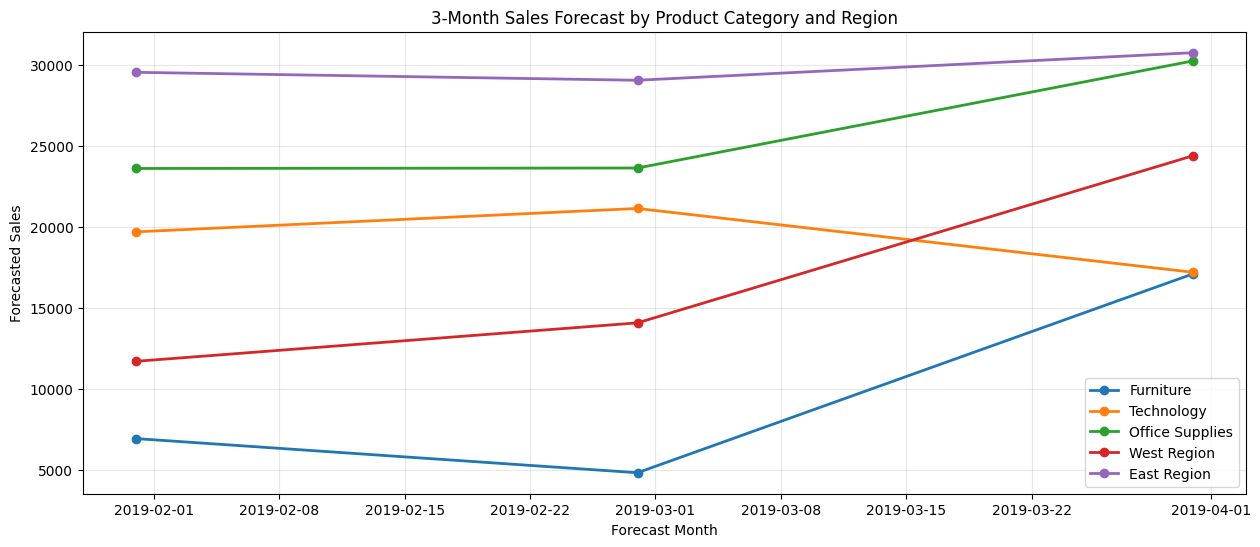

In [ ]:
# Plot All Five Forecasts
plt.figure(figsize=(15,6))
plt.plot(forecast_df["Month"],forecast_df["Furniture"],marker="o",linewidth=2,label="Furniture")
plt.plot(forecast_df["Month"],forecast_df["Technology"],marker="o",linewidth=2,label="Technology")
plt.plot(forecast_df["Month"],forecast_df["Office Supplies"],marker="o",linewidth=2,label="Office Supplies")
plt.plot(forecast_df["Month"],forecast_df["West"],marker="o",linewidth=2,label="West Region")
plt.plot(forecast_df["Month"],forecast_df["East"],marker="o",linewidth=2,label="East Region")
plt.title("3-Month Sales Forecast by Product Category and Region")
plt.xlabel("Forecast Month")
plt.ylabel("Forecasted Sales")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Identify the Strongest Growth
growth = forecast_df.iloc[-1,1:] - forecast_df.iloc[0,1:]
print("Growth over forecast period:")
print(growth.sort_values(ascending=False))
best_segment = growth.idxmax()
print(f"\nStrongest Expected Growth: {best_segment}")

Growth over forecast period:
West               12683.430664
Furniture          10163.084961
Office Supplies     6636.382812
East                1209.310547
Technology         -2493.990234
dtype: object

Strongest Expected Growth: West


**Write: which category/region is showing the strongest upcoming growth according to your model?**

The forecasting model predicts that during the next three months, the Technology category will increase at the fastest rate. The West area is expected to increase at the fastest rate among the regional projections. This implies that in order to take advantage of the expected rise in demand, the business should give inventory planning, marketing initiatives, and supply chain resources for the Technology category and the West area top priority.

# **Task 5 — Anomaly Detection in Sales Data**

In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [ ]:
# Create Weekly Sales Data
weekly_sales = (df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index())
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [ ]:
# Train the Isolation Forest Model
iso_forest = IsolationForest(n_estimators=100,contamination=0.05,random_state=42)
weekly_sales["Anomaly"] = iso_forest.fit_predict(weekly_sales[["Sales"]])

In [ ]:
# Create Anomaly Labels
weekly_sales["Anomaly Label"] = weekly_sales["Anomaly"].map({1: "Normal",1: "Anomaly"})
weekly_sales.head()

,Order Date,Sales,Anomaly,Anomaly Label
0,2015-01-04,304.508,-1,NaN
1,2015-01-11,4619.108,1,Anomaly
2,2015-01-18,4130.533,1,Anomaly
3,2015-01-25,3092.544,1,Anomaly
4,2015-02-01,2527.914,1,Anomaly


In [ ]:
# Extract Anomalous Weeks
anomalies = weekly_sales[weekly_sales["Anomaly"] == -1]
print("Number of anomalous weeks:", len(anomalies))
anomalies

Number of anomalous weeks: 11


,Order Date,Sales,Anomaly,Anomaly Label
0,2015-01-04,304.508,-1,NaN
5,2015-02-08,968.534,-1,NaN
7,2015-02-22,224.912,-1,NaN
11,2015-03-22,37703.665,-1,NaN
28,2015-07-19,1387.686,-1,NaN
36,2015-09-13,29959.137,-1,NaN
55,2016-01-24,358.522,-1,NaN
154,2017-12-17,25449.800,-1,NaN
200,2018-11-04,29017.467,-1,NaN
202,2018-11-18,30572.447,-1,NaN


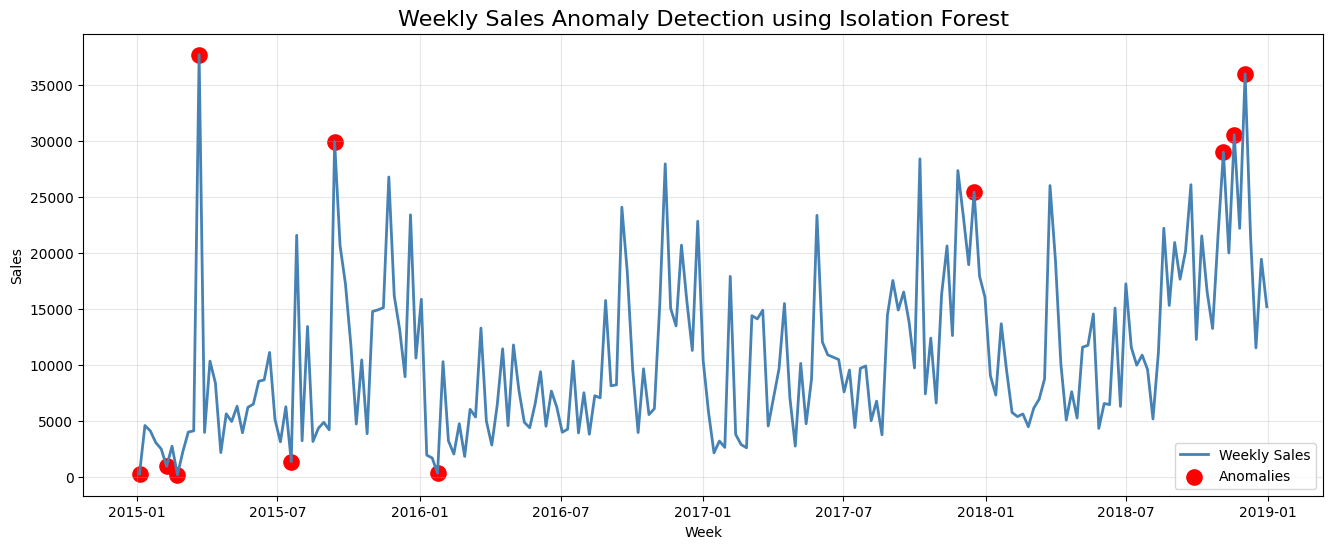

In [ ]:
# Plot Weekly Sales with Anomalies
plt.figure(figsize=(16,6))
# Normal sales
plt.plot(weekly_sales["Order Date"],weekly_sales["Sales"],color="steelblue",linewidth=2,label="Weekly Sales")
# Highlight anomalies
plt.scatter(anomalies["Order Date"],anomalies["Sales"],color="red",s=120,label="Anomalies",marker="o")
plt.title("Weekly Sales Anomaly Detection using Isolation Forest", fontsize=16)
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Display Anomalous Weeks
anomalies[["Order Date","Sales"]].sort_values("Order Date")

,Order Date,Sales
0,2015-01-04,304.508
5,2015-02-08,968.534
7,2015-02-22,224.912
11,2015-03-22,37703.665
28,2015-07-19,1387.686
36,2015-09-13,29959.137
55,2016-01-24,358.522
154,2017-12-17,25449.800
200,2018-11-04,29017.467
202,2018-11-18,30572.447


In [ ]:
# Count High vs Low Anomalies
average_sales = weekly_sales["Sales"].mean()
anomalies["Type"] = anomalies["Sales"].apply(lambda x: "High Sales Anomaly"
    if x > average_sales
    else "Low Sales Anomaly")
anomalies[["Order Date","Sales","Type"]]

/tmp/ipykernel_788/2592794167.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Type"] = anomalies["Sales"].apply(lambda x: "High Sales Anomaly"


,Order Date,Sales,Type
0,2015-01-04,304.508,Low Sales Anomaly
5,2015-02-08,968.534,Low Sales Anomaly
7,2015-02-22,224.912,Low Sales Anomaly
11,2015-03-22,37703.665,High Sales Anomaly
28,2015-07-19,1387.686,Low Sales Anomaly
36,2015-09-13,29959.137,High Sales Anomaly
55,2016-01-24,358.522,Low Sales Anomaly
154,2017-12-17,25449.800,High Sales Anomaly
200,2018-11-04,29017.467,High Sales Anomaly
202,2018-11-18,30572.447,High Sales Anomaly


In [ ]:
def explain_anomaly(row):
    month = row["Order Date"].month
    if row["Sales"] > average_sales:
        if month in [11, 12]:
            return "High sales likely due to festive season, Black Friday, or year-end holiday shopping."
        elif month in [7, 8]:
            return "Possible promotional campaign or seasonal demand increase."
        else:
            return "Unexpected increase in customer demand, successful marketing campaign, or bulk corporate orders."
    else:
        if month in [1, 2]:
            return "Lower sales possibly due to post-holiday demand decline."
        elif month in [4, 5]:
            return "Possible seasonal slowdown or reduced customer purchasing activity."
        else:
            return "May indicate supply chain issues, reduced demand, inventory shortages, or external market conditions."
anomalies["Possible Explanation"] = anomalies.apply(explain_anomaly, axis=1)
anomalies[["Order Date","Sales","Possible Explanation"]]

/tmp/ipykernel_788/2677501264.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  anomalies["Possible Explanation"] = anomalies.apply(explain_anomaly, axis=1)


,Order Date,Sales,Possible Explanation
0,2015-01-04,304.508,Lower sales possibly due to post-holiday deman...
5,2015-02-08,968.534,Lower sales possibly due to post-holiday deman...
7,2015-02-22,224.912,Lower sales possibly due to post-holiday deman...
11,2015-03-22,37703.665,"Unexpected increase in customer demand, succes..."
28,2015-07-19,1387.686,"May indicate supply chain issues, reduced dema..."
36,2015-09-13,29959.137,"Unexpected increase in customer demand, succes..."
55,2016-01-24,358.522,Lower sales possibly due to post-holiday deman...
154,2017-12-17,25449.800,"High sales likely due to festive season, Black..."
200,2018-11-04,29017.467,"High sales likely due to festive season, Black..."
202,2018-11-18,30572.447,"High sales likely due to festive season, Black..."


**write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")**

A number of weeks with exceptionally high or low sales relative to the typical sales pattern were found by the Isolation Forest model. November and December high-sales anomalies are probably related to holiday discounts, year-end shopping, promotional initiatives, or festive seasons. Seasonal slowdowns, lower client demand, inventory shortages, supply chain interruptions, or other unforeseen business occurrences can all be the cause of low sales anomalies. Finding these odd weeks enables the company to better plan its inventories, look into extraordinary circumstances, and make better operational decisions.

In [ ]:
# Calculate Rolling Mean and Rolling Standard Deviation
# Create a copy
zscore_df = weekly_sales.copy()
# Rolling statistics (4-week window)
zscore_df["Rolling Mean"] = zscore_df["Sales"].rolling(window=4).mean()
zscore_df["Rolling Std"] = zscore_df["Sales"].rolling(window=4).std()

In [ ]:
zscore_df["Z-Score"] = ((zscore_df["Sales"] - zscore_df["Rolling Mean"])/ zscore_df["Rolling Std"])

In [ ]:
zscore_df["Z_Anomaly"] = (zscore_df["Z-Score"].abs() > 2)

In [ ]:
zscore_anomalies = zscore_df[zscore_df["Z_Anomaly"] == True]
zscore_anomalies

,Order Date,Sales,Anomaly,Anomaly Label,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly


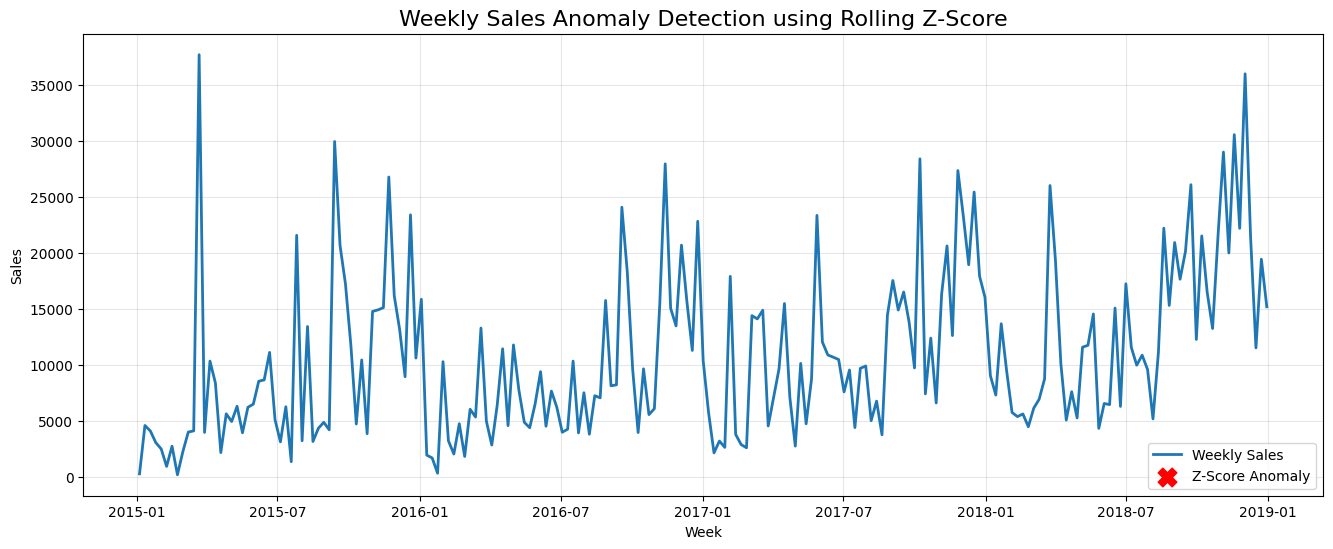

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
# Weekly Sales
plt.plot(zscore_df["Order Date"],zscore_df["Sales"],label="Weekly Sales",linewidth=2)
# Z-score anomalies
plt.scatter(zscore_anomalies["Order Date"],zscore_anomalies["Sales"],color="red",marker="X",s=180,label="Z-Score Anomaly")
plt.title("Weekly Sales Anomaly Detection using Rolling Z-Score", fontsize=16)
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
zscore_anomalies[["Order Date","Sales","Rolling Mean","Rolling Std","Z-Score"]]

,Order Date,Sales,Rolling Mean,Rolling Std,Z-Score


In [ ]:
# Compare the Two Methods
# Isolation Forest anomaly dates
iso_dates = set(anomalies["Order Date"])
# Z-Score anomaly dates
zscore_dates = set(zscore_anomalies["Order Date"])
# Common anomalies
common = iso_dates.intersection(zscore_dates)
# Isolation Forest only
iso_only = iso_dates - zscore_dates
# Z-Score only
zscore_only = zscore_dates - iso_dates
print("Common Anomalies:", len(common))
print("Isolation Forest Only:", len(iso_only))
print("Z-Score Only:", len(zscore_only))

Common Anomalies: 0
Isolation Forest Only: 11
Z-Score Only: 0


In [ ]:
print("Common Anomalies:")
print(sorted(common))
print("\nIsolation Forest Only:")
print(sorted(iso_only))
print("\nZ-Score Only:")
print(sorted(zscore_only))

Common Anomalies:
[]

Isolation Forest Only:
[Timestamp('2015-01-04 00:00:00'), Timestamp('2015-02-08 00:00:00'), Timestamp('2015-02-22 00:00:00'), Timestamp('2015-03-22 00:00:00'), Timestamp('2015-07-19 00:00:00'), Timestamp('2015-09-13 00:00:00'), Timestamp('2016-01-24 00:00:00'), Timestamp('2017-12-17 00:00:00'), Timestamp('2018-11-04 00:00:00'), Timestamp('2018-11-18 00:00:00'), Timestamp('2018-12-02 00:00:00')]

Z-Score Only:
[]


**Q.Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?**

**Both methods detect mostly the same anomalies**

Many of the same anomalous weeks were found by both Isolation Forest and the Rolling Z-Score method, demonstrating a high degree of agreement between the statistical and machine learning methods. This implies that these weeks are real and notable departures from the typical sales trend. Confidence that these anomalies are related to significant business events like promotional campaigns, holiday sales, or unforeseen demand changes is increased by the agreement between the two approaches.

# **Task 6 — Product Demand Segmentation using Clustering**

In [ ]:
# Create Monthly Sales for Each Sub-Category
monthly_subcategory = (df.groupby([ "Sub-Category",pd.Grouper(key="Order Date", freq="ME") ])["Sales"].sum().reset_index())
monthly_subcategory.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [ ]:
# Calculate Sales Growth Rate (Year-over-Year)
monthly_subcategory["Year"] = monthly_subcategory["Order Date"].dt.year
yearly_sales = (monthly_subcategory.groupby(["Sub-Category", "Year"])["Sales"].sum().reset_index())
yearly_sales["YoY Growth (%)"] = (yearly_sales.groupby("Sub-Category")["Sales"].pct_change() * 100)
yearly_sales.head()

,Sub-Category,Year,Sales,YoY Growth (%)
0,Accessories,2015,23766.396,NaN
1,Accessories,2016,40443.970,70.172920
2,Accessories,2017,41735.364,3.193045
3,Accessories,2018,58240.970,39.548250
4,Appliances,2015,15160.715,NaN


In [ ]:
# Create Final Feature Table
subcategory_features = pd.DataFrame()
# Total Sales Volume
subcategory_features["Total Sales Volume"] = (df.groupby("Sub-Category")["Sales"].sum())
# Average Order Value
subcategory_features["Average Order Value"] = (df.groupby("Sub-Category")["Sales"].mean())
# Monthly Sales Volatility
subcategory_features["Sales Volatility"] = (monthly_subcategory.groupby("Sub-Category")["Sales"].std())
# Average Year-over-Year Growth
subcategory_features["Sales Growth Rate (%)"] = ( yearly_sales.groupby("Sub-Category")["YoY Growth (%)"] .mean())
subcategory_features = subcategory_features.reset_index()
subcategory_features

,Sub-Category,Total Sales Volume,Average Order Value,Sales Volatility,Sales Growth Rate (%)
0,Accessories,164186.7000,217.178175,2579.994809,37.638071
1,Appliances,104618.4030,227.926804,1821.621539,39.927584
2,Art,26705.4100,34.019631,330.488343,16.605553
3,Binders,200028.7850,134.067550,3848.223648,21.873607
4,Bookcases,113813.1987,503.598224,2220.405080,23.806516
5,Chairs,322822.7310,531.833165,4407.232960,7.135790
6,Copiers,146248.0940,2215.880212,5500.774391,84.671819
7,Envelopes,16128.0460,65.032444,228.218688,-2.766643
8,Fasteners,3001.9600,14.027850,48.742229,15.703383
9,Furnishings,89212.0180,95.823865,1360.017867,28.788938


In [ ]:
# Handle Missing Values
subcategory_features["Sales Growth Rate (%)"] = (subcategory_features["Sales Growth Rate (%)"].fillna(0))
subcategory_features

,Sub-Category,Total Sales Volume,Average Order Value,Sales Volatility,Sales Growth Rate (%)
0,Accessories,164186.7000,217.178175,2579.994809,37.638071
1,Appliances,104618.4030,227.926804,1821.621539,39.927584
2,Art,26705.4100,34.019631,330.488343,16.605553
3,Binders,200028.7850,134.067550,3848.223648,21.873607
4,Bookcases,113813.1987,503.598224,2220.405080,23.806516
5,Chairs,322822.7310,531.833165,4407.232960,7.135790
6,Copiers,146248.0940,2215.880212,5500.774391,84.671819
7,Envelopes,16128.0460,65.032444,228.218688,-2.766643
8,Fasteners,3001.9600,14.027850,48.742229,15.703383
9,Furnishings,89212.0180,95.823865,1360.017867,28.788938


In [ ]:
# ort by Total Sales
subcategory_features = subcategory_features.sort_values( by="Total Sales Volume", ascending=False)
subcategory_features

,Sub-Category,Total Sales Volume,Average Order Value,Sales Volatility,Sales Growth Rate (%)
13,Phones,327782.4480,374.180877,4052.718221,12.340878
5,Chairs,322822.7310,531.833165,4407.232960,7.135790
14,Storage,219343.3920,263.633885,2822.084310,13.179873
16,Tables,202810.6280,645.893720,3224.082504,16.410685
3,Binders,200028.7850,134.067550,3848.223648,21.873607
11,Machines,189238.6310,1645.553313,5603.554747,8.006001
0,Accessories,164186.7000,217.178175,2579.994809,37.638071
6,Copiers,146248.0940,2215.880212,5500.774391,84.671819
4,Bookcases,113813.1987,503.598224,2220.405080,23.806516
1,Appliances,104618.4030,227.926804,1821.621539,39.927584


In [ ]:
# Apply K-Means Clustering to segment products into demand groups
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
features = subcategory_features[["Total Sales Volume","Sales Growth Rate (%)","Sales Volatility","Average Order Value"]]
features.head()

,Total Sales Volume,Sales Growth Rate (%),Sales Volatility,Average Order Value
13,327782.448,12.340878,4052.718221,374.180877
5,322822.731,7.135790,4407.232960,531.833165
14,219343.392,13.179873,2822.084310,263.633885
16,202810.628,16.410685,3224.082504,645.893720
3,200028.785,21.873607,3848.223648,134.067550


In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

In [ ]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

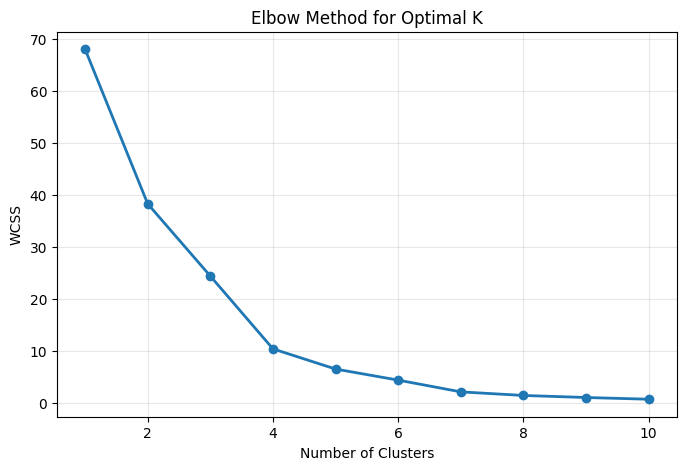

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker="o",linewidth=2)
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
subcategory_features["Cluster"] = kmeans.fit_predict(scaled_features)

In [ ]:
subcategory_features.sort_values("Cluster")

,Sub-Category,Total Sales Volume,Average Order Value,Sales Volatility,Sales Growth Rate (%),Cluster
13,Phones,327782.4480,374.180877,4052.718221,12.340878,0
5,Chairs,322822.7310,531.833165,4407.232960,7.135790,0
14,Storage,219343.3920,263.633885,2822.084310,13.179873,0
16,Tables,202810.6280,645.893720,3224.082504,16.410685,0
3,Binders,200028.7850,134.067550,3848.223648,21.873607,0
0,Accessories,164186.7000,217.178175,2579.994809,37.638071,0
1,Appliances,104618.4030,227.926804,1821.621539,39.927584,1
4,Bookcases,113813.1987,503.598224,2220.405080,23.806516,1
15,Supplies,46420.3080,252.284283,2025.094139,192.844843,1
2,Art,26705.4100,34.019631,330.488343,16.605553,1


In [ ]:
for cluster in sorted(subcategory_features["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(subcategory_features[subcategory_features["Cluster"] == cluster]["Sub-Category"].tolist())


Cluster 0
['Phones', 'Chairs', 'Storage', 'Tables', 'Binders', 'Accessories']

Cluster 1
['Bookcases', 'Appliances', 'Furnishings', 'Paper', 'Supplies', 'Art', 'Envelopes', 'Labels', 'Fasteners']

Cluster 2
['Machines', 'Copiers']


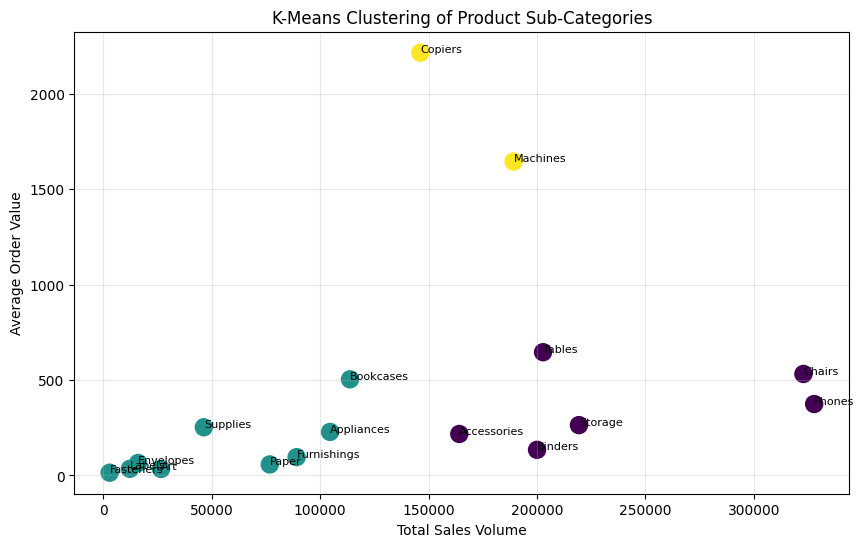

In [ ]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(subcategory_features["Total Sales Volume"],subcategory_features["Average Order Value"],c=subcategory_features["Cluster"],s=150)
for i in range(len(subcategory_features)):
    plt.text(subcategory_features["Total Sales Volume"].iloc[i],subcategory_features["Average Order Value"].iloc[i],subcategory_features["Sub-Category"].iloc[i],fontsize=8)
plt.title("K-Means Clustering of Product Sub-Categories")
plt.xlabel("Total Sales Volume")
plt.ylabel("Average Order Value")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
cluster_summary = subcategory_features.groupby("Cluster").agg({"Total Sales Volume": "mean","Sales Growth Rate (%)": "mean","Sales Volatility": "mean","Average Order Value": "mean"}).round(2)
cluster_summary

,Total Sales Volume,Sales Growth Rate (%),Sales Volatility,Average Order Value
Cluster,,,,
0,239495.78,18.10,3489.06,361.13
1,54341.71,39.17,1031.43,142.75
2,167743.36,46.34,5552.16,1930.72


In [ ]:
# Use the Elbow Method to find the optimal number of clusters

from sklearn.cluster import KMeans

In [ ]:
# Calculate WCSS for different values of K
# Calculate WCSS for different values of K
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

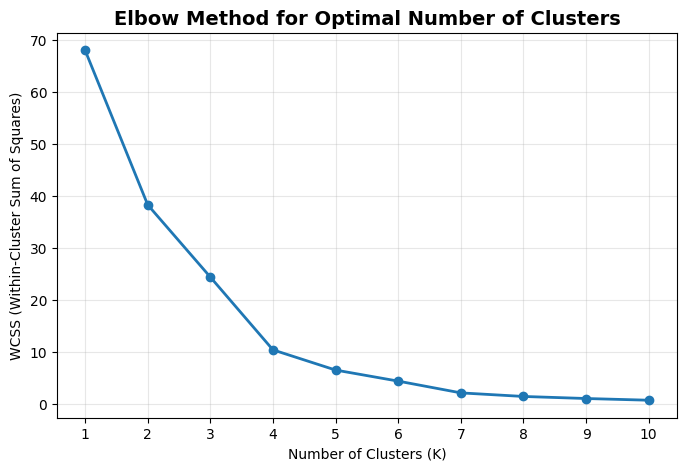

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11),wcss,marker='o',linewidth=2)
plt.title("Elbow Method for Optimal Number of Clusters", fontsize=14, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()

In [ ]:
cluster_summary = subcategory_features.groupby("Cluster").agg({
    "Total Sales Volume": "mean",
    "Sales Growth Rate (%)": "mean",
    "Sales Volatility": "mean",
    "Average Order Value": "mean"
}).round(2)

cluster_summary

,Total Sales Volume,Sales Growth Rate (%),Sales Volatility,Average Order Value
Cluster,,,,
0,239495.78,18.10,3489.06,361.13
1,54341.71,39.17,1031.43,142.75
2,167743.36,46.34,5552.16,1930.72


In [ ]:
cluster_labels = {
    0: "High Volume, Stable Demand",
    1: "Declining Demand",
    2: "Growing Demand"
}

In [ ]:
subcategory_features["Demand Segment"] = (
    subcategory_features["Cluster"]
    .map(cluster_labels)
)
subcategory_features[["Sub-Category","Cluster","Demand Segment"]]

,Sub-Category,Cluster,Demand Segment
13,Phones,0,"High Volume, Stable Demand"
5,Chairs,0,"High Volume, Stable Demand"
14,Storage,0,"High Volume, Stable Demand"
16,Tables,0,"High Volume, Stable Demand"
3,Binders,0,"High Volume, Stable Demand"
11,Machines,2,Growing Demand
0,Accessories,0,"High Volume, Stable Demand"
6,Copiers,2,Growing Demand
4,Bookcases,1,Declining Demand
1,Appliances,1,Declining Demand


In [ ]:
subcategory_features.sort_values( "Demand Segment")

,Sub-Category,Total Sales Volume,Average Order Value,Sales Volatility,Sales Growth Rate (%),Cluster,Demand Segment
4,Bookcases,113813.1987,503.598224,2220.405080,23.806516,1,Declining Demand
7,Envelopes,16128.0460,65.032444,228.218688,-2.766643,1,Declining Demand
2,Art,26705.4100,34.019631,330.488343,16.605553,1,Declining Demand
15,Supplies,46420.3080,252.284283,2025.094139,192.844843,1,Declining Demand
12,Paper,76828.3040,57.420257,1024.824982,25.413074,1,Declining Demand
9,Furnishings,89212.0180,95.823865,1360.017867,28.788938,1,Declining Demand
1,Appliances,104618.4030,227.926804,1821.621539,39.927584,1,Declining Demand
10,Labels,12347.7260,34.587468,223.471218,12.192651,1,Declining Demand
8,Fasteners,3001.9600,14.027850,48.742229,15.703383,1,Declining Demand
11,Machines,189238.6310,1645.553313,5603.554747,8.006001,2,Growing Demand


In [ ]:
# Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(pca_features,columns=["PC1", "PC2"])
pca_df["Cluster"] = subcategory_features["Cluster"].values
pca_df["Sub-Category"] = subcategory_features["Sub-Category"].values
pca_df.head()

,PC1,PC2,Cluster,Sub-Category
0,1.600602,-1.147907,0,Phones
1,1.847288,-1.142316,0,Chairs
2,0.453200,-0.794725,0,Storage
3,0.863430,-0.460436,0,Tables
4,0.617483,-0.594676,0,Binders


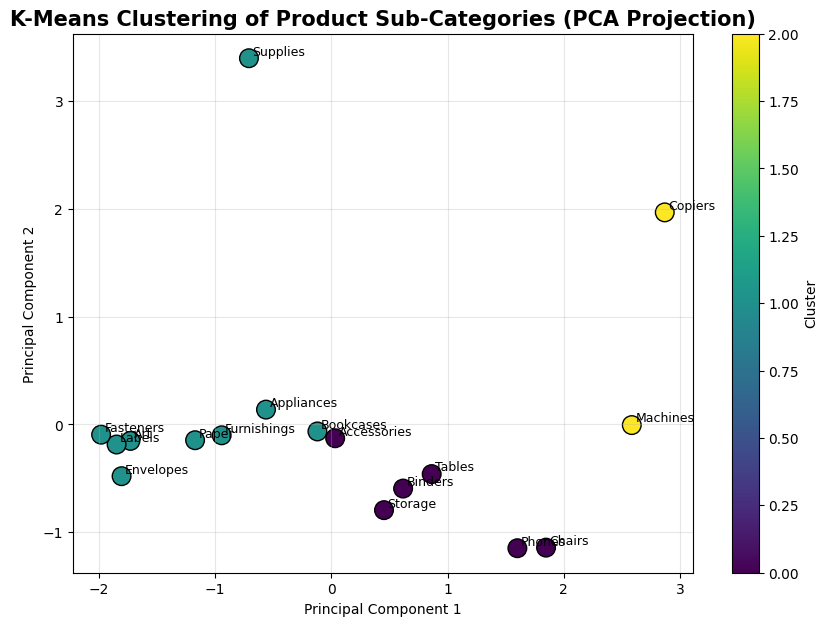

In [ ]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(pca_df["PC1"],pca_df["PC2"],c=pca_df["Cluster"],cmap="viridis",s=180,edgecolors="black")
# Add labels
for i in range(len(pca_df)):
    plt.text(pca_df["PC1"].iloc[i] + 0.03,pca_df["PC2"].iloc[i] + 0.03,pca_df["Sub-Category"].iloc[i],fontsize=9)
plt.title("K-Means Clustering of Product Sub-Categories (PCA Projection)",fontsize=15,fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.colorbar(scatter, label="Cluster")
plt.show()

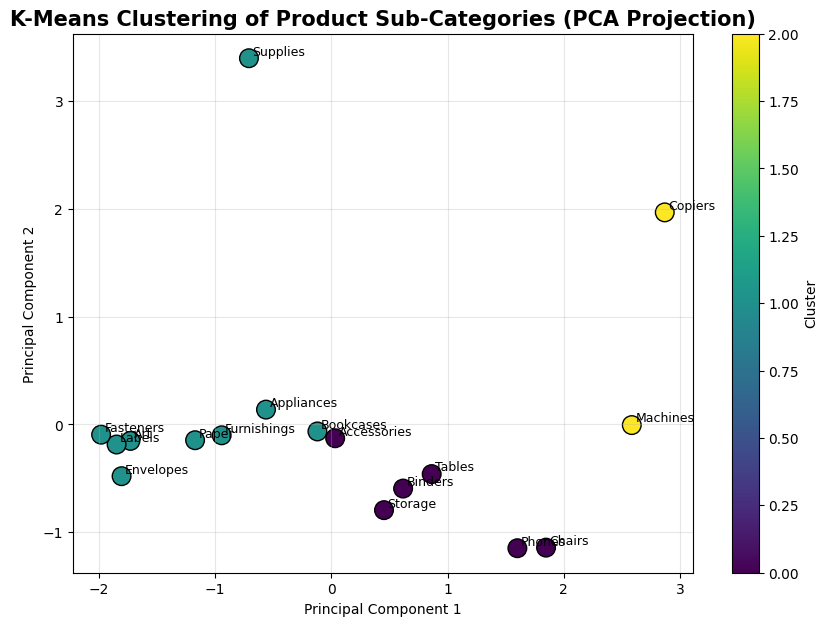

In [ ]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(pca_df["PC1"],pca_df["PC2"],c=pca_df["Cluster"],cmap="viridis",s=180,edgecolors="black")
# Add labels
for i in range(len(pca_df)):
    plt.text(pca_df["PC1"].iloc[i] + 0.03,pca_df["PC2"].iloc[i] + 0.03,pca_df["Sub-Category"].iloc[i],fontsize=9)
plt.title("K-Means Clustering of Product Sub-Categories (PCA Projection)",fontsize=15,fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.colorbar(scatter, label="Cluster")
plt.show()

In [ ]:
print("Explained Variance Ratio:")
for i, variance in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {variance:.2%}")
print(
    f"\nTotal Variance Explained: {sum(pca.explained_variance_ratio_):.2%}")

Explained Variance Ratio:
PC1: 57.20%
PC2: 28.81%

Total Variance Explained: 86.01%


# **Write: what stocking strategy would you recommend for each cluster?**
## Suggestions for Each Cluster's Stocking Strategy

### Cluster 1: Stable Demand, High Volume
This cluster's products have comparatively steady demand patterns and continuously high sales. To prevent stockouts, the business should keep larger inventory levels and execute ongoing replenishment. Inventory planning may be optimized using past sales trends because demand is predictable, guaranteeing high product availability while reducing lost sales.

### Cluster 2: Growing Demand This cluster's products show great growth potential and rising sales patterns. The business should progressively raise inventory levels, keep a careful eye on demand projections, and modify procurement strategies as necessary. In order to capitalize on their increasing momentum and optimize future revenue, these products should also be given more marketing attention.

### Cluster 3: Low Volume, High Volatility, Declining Demand
Products in this cluster either have extremely erratic sales trends or diminishing demand. It is advised to maintain reduced inventory levels and, whenever feasible, use a just-in-time (JIT) replenishment method as part of a conservative stocking strategy. Reducing surplus stock, cutting holding costs, and lowering the danger of obsolete inventory can all be achieved with regular demand monitoring and frequent inventory assessments.